<a href="https://www.kaggle.com/code/lalit7881/global-trade-disruptions-analysis-eda?scriptVersionId=319976331" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sergionefedov/global-supply-chain-and-trade-disruptions-25-years/trade_flows.csv
/kaggle/input/datasets/sergionefedov/global-supply-chain-and-trade-disruptions-25-years/disruption_events.csv
/kaggle/input/datasets/sergionefedov/global-supply-chain-and-trade-disruptions-25-years/shipping_rates.csv
/kaggle/input/datasets/sergionefedov/global-supply-chain-and-trade-disruptions-25-years/port_congestion.csv
/kaggle/input/datasets/sergionefedov/global-supply-chain-and-trade-disruptions-25-years/industry_exposure.csv


## Loading dataset

In [2]:
# Dataset Folder Path
dataset_path = "/kaggle/input/datasets/sergionefedov/global-supply-chain-and-trade-disruptions-25-years"

# Load CSV Files using Pandas
trade_flows = pd.read_csv(f"{dataset_path}/trade_flows.csv")
disruption_events = pd.read_csv(f"{dataset_path}/disruption_events.csv")
shipping_rates = pd.read_csv(f"{dataset_path}/shipping_rates.csv")
port_congestion = pd.read_csv(f"{dataset_path}/port_congestion.csv")
industry_exposure = pd.read_csv(f"{dataset_path}/industry_exposure.csv")

# Display First 5 Rows
print("Trade Flows Dataset")
print(trade_flows.head())

print("\nDisruption Events Dataset")
print(disruption_events.head())

print("\nShipping Rates Dataset")
print(shipping_rates.head())

print("\nPort Congestion Dataset")
print(port_congestion.head())

print("\nIndustry Exposure Dataset")
print(industry_exposure.head())

Trade Flows Dataset
   year   exporter importer trade_category          key_goods  \
0  2000  Australia    China    commodities  iron ore,coal,LNG   
1  2001  Australia    China    commodities  iron ore,coal,LNG   
2  2002  Australia    China    commodities  iron ore,coal,LNG   
3  2003  Australia    China    commodities  iron ore,coal,LNG   
4  2004  Australia    China    commodities  iron ore,coal,LNG   

   trade_value_bn_usd  yoy_growth_pct  effective_tariff_rate_pct  \
0               23.18             NaN                        2.5   
1               26.71           15.23                        2.5   
2               26.44           -1.01                        2.5   
3               27.68            4.69                        2.5   
4               29.89            7.98                        2.5   

   trade_active  supply_chain_integrated  concentration_risk  
0             1                        0               0.158  
1             1                        0              

In [3]:
print("\nTrade Flows Sample")
print(trade_flows.head())

print("\nDisruption Events Sample")
print(disruption_events.head())


Trade Flows Sample
   year   exporter importer trade_category          key_goods  \
0  2000  Australia    China    commodities  iron ore,coal,LNG   
1  2001  Australia    China    commodities  iron ore,coal,LNG   
2  2002  Australia    China    commodities  iron ore,coal,LNG   
3  2003  Australia    China    commodities  iron ore,coal,LNG   
4  2004  Australia    China    commodities  iron ore,coal,LNG   

   trade_value_bn_usd  yoy_growth_pct  effective_tariff_rate_pct  \
0               23.18             NaN                        2.5   
1               26.71           15.23                        2.5   
2               26.44           -1.01                        2.5   
3               27.68            4.69                        2.5   
4               29.89            7.98                        2.5   

   trade_active  supply_chain_integrated  concentration_risk  
0             1                        0               0.158  
1             1                        0              

In [4]:
print("\nTrade Flows Info")
print(trade_flows.info())

print("\nShipping Rates Info")
print(shipping_rates.info())


Trade Flows Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       1250 non-null   int64  
 1   exporter                   1250 non-null   object 
 2   importer                   1250 non-null   object 
 3   trade_category             1250 non-null   object 
 4   key_goods                  1250 non-null   object 
 5   trade_value_bn_usd         1250 non-null   float64
 6   yoy_growth_pct             1200 non-null   float64
 7   effective_tariff_rate_pct  1250 non-null   float64
 8   trade_active               1250 non-null   int64  
 9   supply_chain_integrated    1250 non-null   int64  
 10  concentration_risk         1250 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 107.6+ KB
None

Shipping Rates Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 ent

In [5]:
print("\nMissing Values in Trade Flows")
print(trade_flows.isnull().sum())

print("\nMissing Values in Shipping Rates")
print(shipping_rates.isnull().sum())


Missing Values in Trade Flows
year                          0
exporter                      0
importer                      0
trade_category                0
key_goods                     0
trade_value_bn_usd            0
yoy_growth_pct               50
effective_tariff_rate_pct     0
trade_active                  0
supply_chain_integrated       0
concentration_risk            0
dtype: int64

Missing Values in Shipping Rates
date                               0
year                               0
month                              0
baltic_dry_index                   0
container_rate_usd_40ft            0
air_cargo_rate_usd_kg              0
bdi_mom_change_pct                 1
container_yoy_pct                 12
tanker_rate_aframax_usd_day        0
bulk_carrier_handysize_usd_day     0
supply_chain_pressure_index        0
on_time_delivery_pct               0
dtype: int64


In [6]:
print("\nDuplicate Rows in Trade Flows:", trade_flows.duplicated().sum())
print("Duplicate Rows in Shipping Rates:", shipping_rates.duplicated().sum())


Duplicate Rows in Trade Flows: 0
Duplicate Rows in Shipping Rates: 0


In [7]:
print("\nTrade Flows Statistics")
print(trade_flows.describe())

print("\nShipping Rates Statistics")
print(shipping_rates.describe())


Trade Flows Statistics
              year  trade_value_bn_usd  yoy_growth_pct  \
count  1250.000000         1250.000000     1200.000000   
mean   2012.000000           95.483208        2.436508   
std       7.213989          120.025818       10.404324   
min    2000.000000            4.650000      -68.040000   
25%    2006.000000           31.742500       -3.152500   
50%    2012.000000           56.010000        2.105000   
75%    2018.000000           85.572500        7.305000   
max    2024.000000          576.600000      217.010000   

       effective_tariff_rate_pct  trade_active  supply_chain_integrated  \
count                1250.000000   1250.000000              1250.000000   
mean                    2.780400      0.980000                 0.420000   
std                     2.501236      0.140056                 0.493756   
min                     2.500000      0.000000                 0.000000   
25%                     2.500000      1.000000                 0.000000   
50%

In [8]:
print("\nTrade Flows Data Types")
print(trade_flows.dtypes)


Trade Flows Data Types
year                           int64
exporter                      object
importer                      object
trade_category                object
key_goods                     object
trade_value_bn_usd           float64
yoy_growth_pct               float64
effective_tariff_rate_pct    float64
trade_active                   int64
supply_chain_integrated        int64
concentration_risk           float64
dtype: object


In [9]:
for col in trade_flows.select_dtypes(include='object').columns:
    print(f"\nUnique values in {col}:")
    print(trade_flows[col].nunique())



Unique values in exporter:
38

Unique values in importer:
9

Unique values in trade_category:
18

Unique values in key_goods:
46


In [10]:
# Remove duplicate rows
trade_flows = trade_flows.drop_duplicates()

# Fill missing numeric values with median
numeric_cols = trade_flows.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    trade_flows[col] = trade_flows[col].fillna(trade_flows[col].median())

# Fill missing categorical values with mode
categorical_cols = trade_flows.select_dtypes(include='object').columns

for col in categorical_cols:
    trade_flows[col] = trade_flows[col].fillna(trade_flows[col].mode()[0])


In [11]:
print("\nCorrelation Matrix")
print(trade_flows.corr(numeric_only=True))



Correlation Matrix
                                   year  trade_value_bn_usd  yoy_growth_pct  \
year                       1.000000e+00            0.082615       -0.108449   
trade_value_bn_usd         8.261473e-02            1.000000        0.009631   
yoy_growth_pct            -1.084486e-01            0.009631        1.000000   
effective_tariff_rate_pct  1.512858e-01            0.012434        0.118273   
trade_active              -1.363102e-14            0.032661       -0.080787   
supply_chain_integrated    1.694533e-14            0.259709       -0.012431   
concentration_risk         2.160508e-02           -0.030322        0.005805   

                           effective_tariff_rate_pct  trade_active  \
year                                        0.151286 -1.363102e-14   
trade_value_bn_usd                          0.012434  3.266081e-02   
yoy_growth_pct                              0.118273 -8.078664e-02   
effective_tariff_rate_pct                   1.000000 -2.068148e-01 

In [12]:
numerical_cols = trade_flows.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = trade_flows.select_dtypes(include='object').columns

print("\nNumerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)


Numerical Columns
Index(['year', 'trade_value_bn_usd', 'yoy_growth_pct',
       'effective_tariff_rate_pct', 'trade_active', 'supply_chain_integrated',
       'concentration_risk'],
      dtype='object')

Categorical Columns
Index(['exporter', 'importer', 'trade_category', 'key_goods'], dtype='object')


## EDA

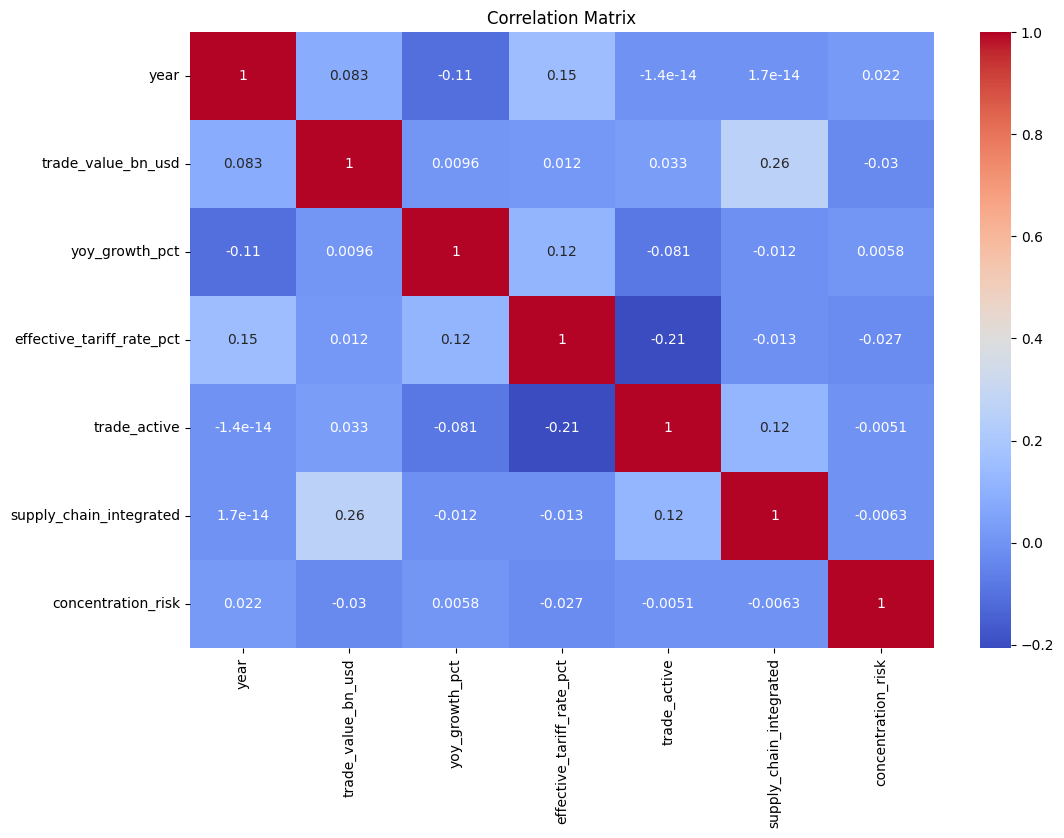

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(
    trade_flows[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()


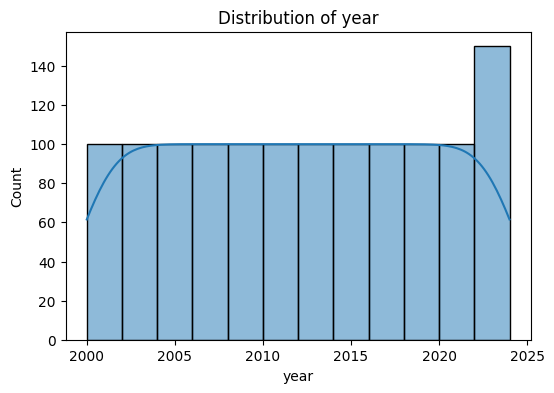

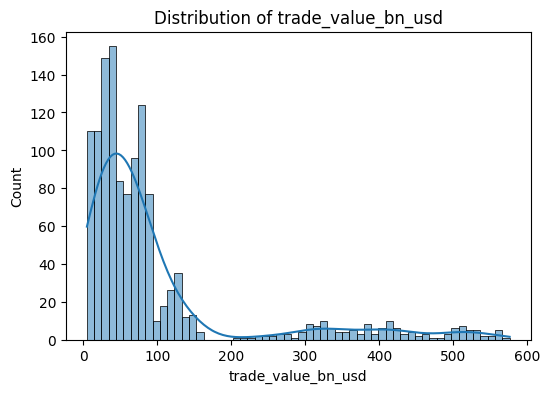

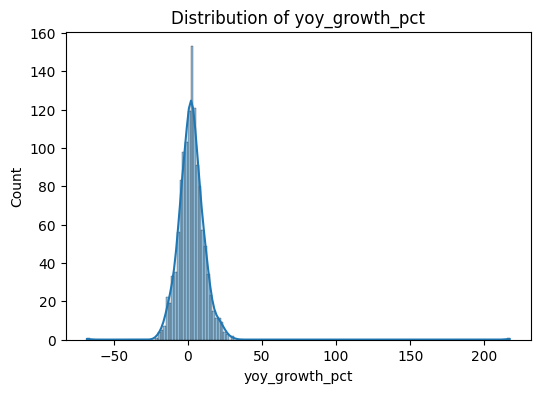

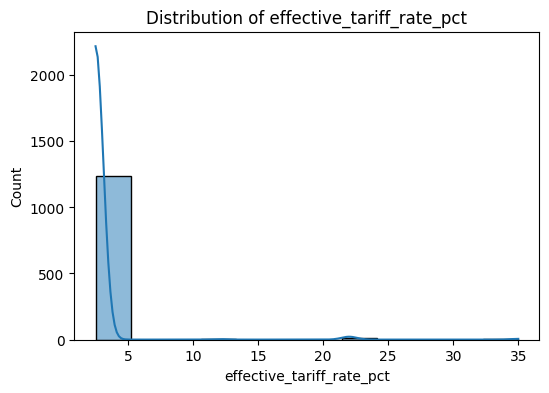

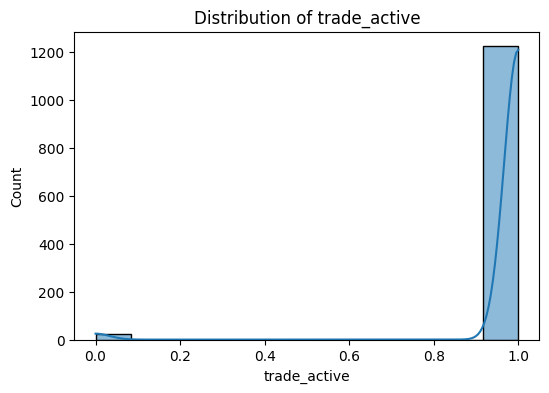

In [14]:
for col in numerical_cols[:5]:
    plt.figure(figsize=(6,4))
    sns.histplot(trade_flows[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

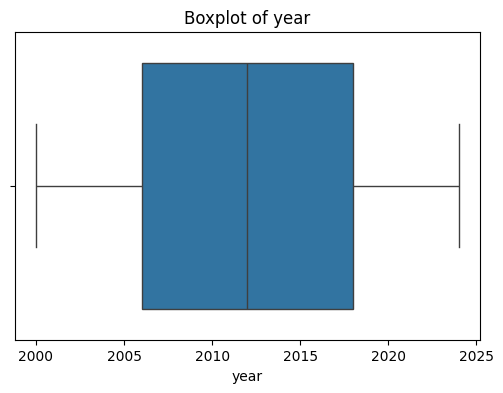

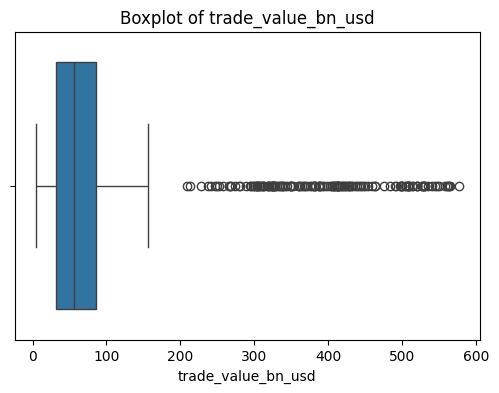

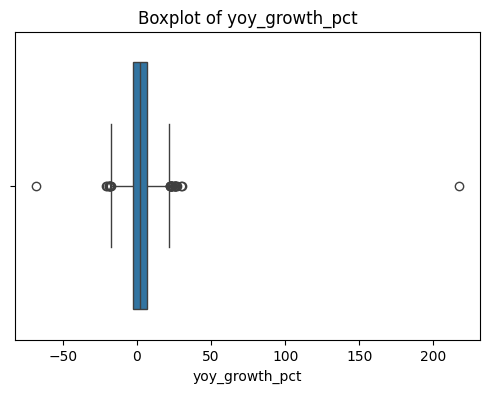

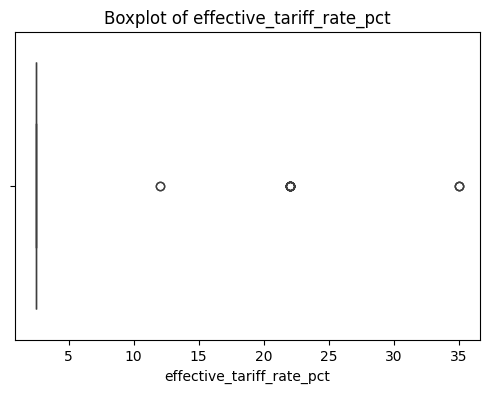

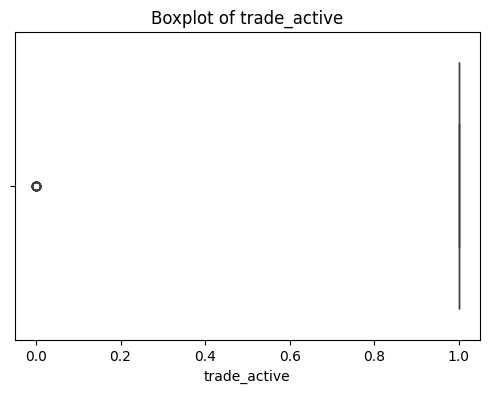

In [15]:
for col in numerical_cols[:5]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=trade_flows[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

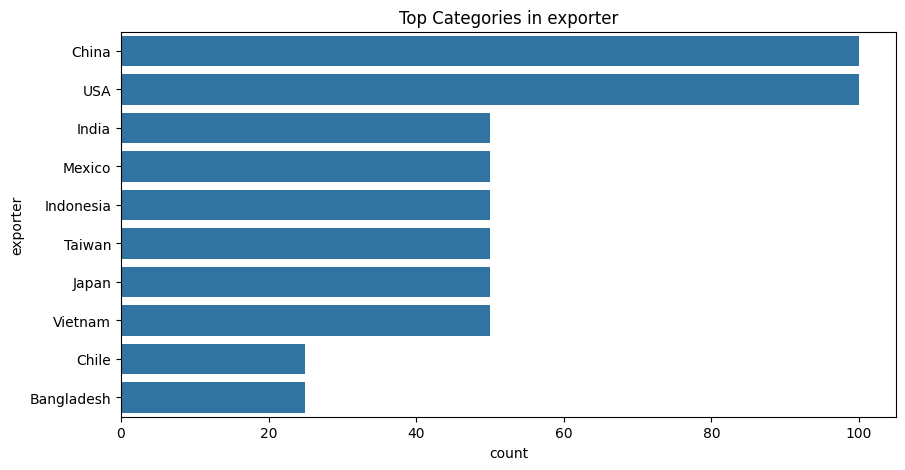

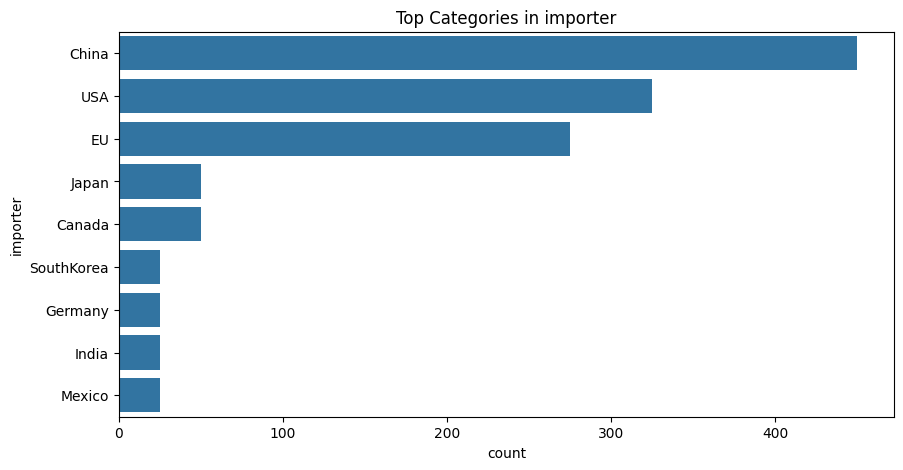

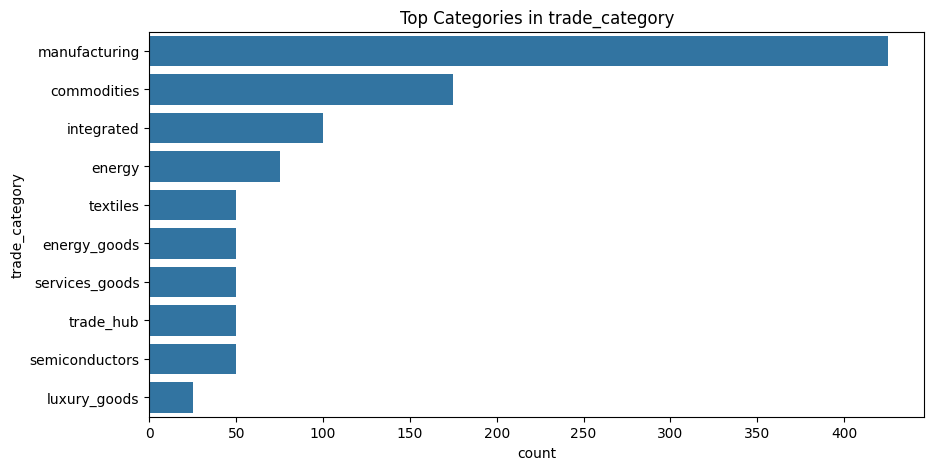

In [16]:
for col in categorical_cols[:3]:
    plt.figure(figsize=(10,5))
    sns.countplot(
        y=trade_flows[col],
        order=trade_flows[col].value_counts().index[:10]
    )
    plt.title(f"Top Categories in {col}")
    plt.show()

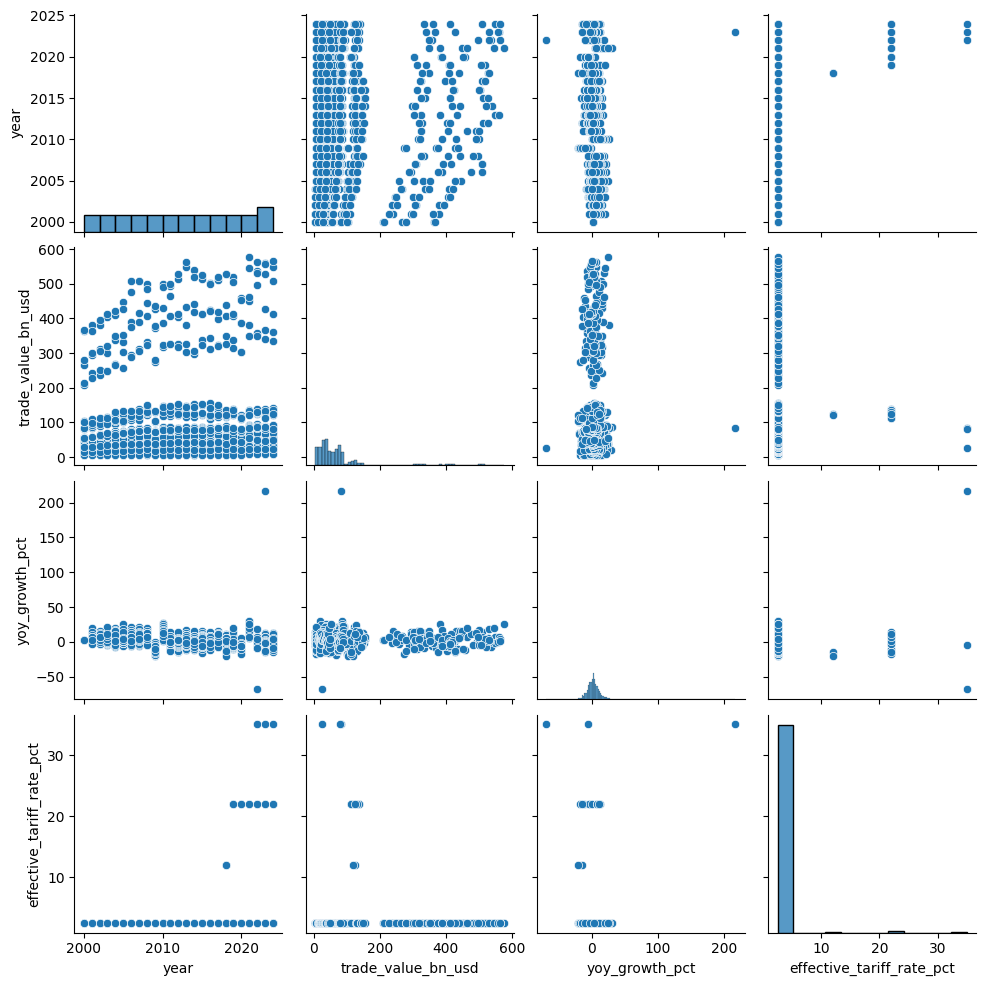

In [17]:
sns.pairplot(trade_flows[numerical_cols[:4]])
plt.show()

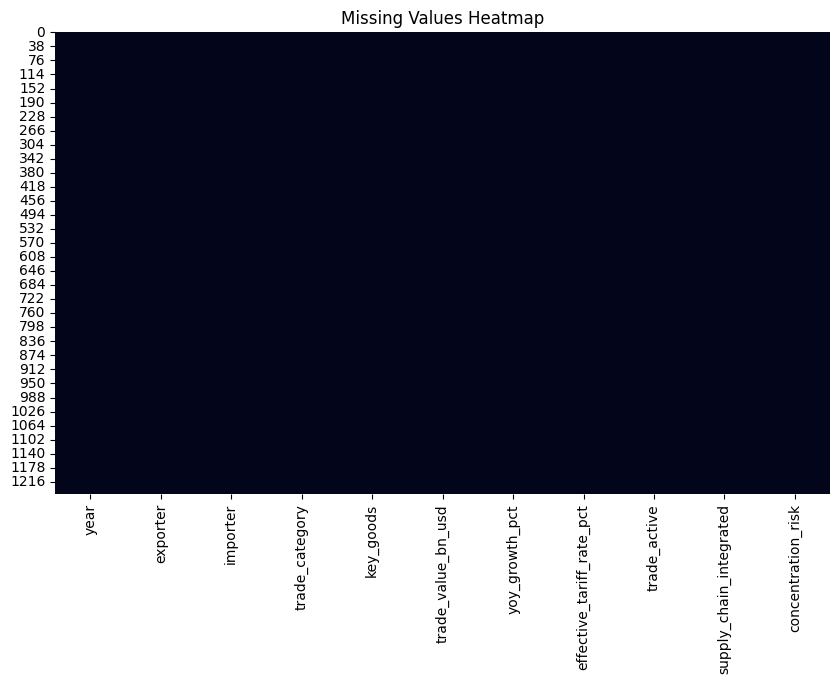

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(trade_flows.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [19]:
if len(categorical_cols) > 0 and len(numerical_cols) > 0:
    group_data = trade_flows.groupby(categorical_cols[0])[numerical_cols[0]].mean()

    print("\nGroupby Analysis")
    print(group_data)



Groupby Analysis
exporter
Australia       2012.0
Bangladesh      2012.0
Brazil          2012.0
Canada          2012.0
Chile           2012.0
China           2012.0
Colombia        2012.0
EU              2012.0
Egypt           2012.0
France          2012.0
Germany         2012.0
India           2012.0
Indonesia       2012.0
Israel          2012.0
Japan           2012.0
Malaysia        2012.0
Mexico          2012.0
Morocco         2012.0
Netherlands     2012.0
Nigeria         2012.0
Pakistan        2012.0
Peru            2012.0
Philippines     2012.0
Poland          2012.0
Russia          2012.0
Saudi Arabia    2012.0
Singapore       2012.0
South Africa    2012.0
SouthKorea      2012.0
Sweden          2012.0
Switzerland     2012.0
Taiwan          2012.0
Thailand        2012.0
Turkey          2012.0
UAE             2012.0
UK              2012.0
USA             2012.0
Vietnam         2012.0
Name: year, dtype: float64


In [20]:
print("\nTop 10 Rows")
print(trade_flows.head(10))


Top 10 Rows
   year   exporter importer trade_category          key_goods  \
0  2000  Australia    China    commodities  iron ore,coal,LNG   
1  2001  Australia    China    commodities  iron ore,coal,LNG   
2  2002  Australia    China    commodities  iron ore,coal,LNG   
3  2003  Australia    China    commodities  iron ore,coal,LNG   
4  2004  Australia    China    commodities  iron ore,coal,LNG   
5  2005  Australia    China    commodities  iron ore,coal,LNG   
6  2006  Australia    China    commodities  iron ore,coal,LNG   
7  2007  Australia    China    commodities  iron ore,coal,LNG   
8  2008  Australia    China    commodities  iron ore,coal,LNG   
9  2009  Australia    China    commodities  iron ore,coal,LNG   

   trade_value_bn_usd  yoy_growth_pct  effective_tariff_rate_pct  \
0               23.18           2.105                        2.5   
1               26.71          15.230                        2.5   
2               26.44          -1.010                        2.5   

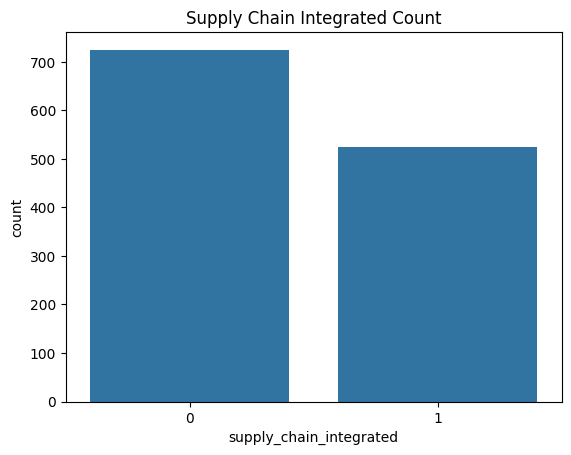

In [21]:
sns.countplot(
    x='supply_chain_integrated',
    data=trade_flows
)

plt.title("Supply Chain Integrated Count")

plt.show()

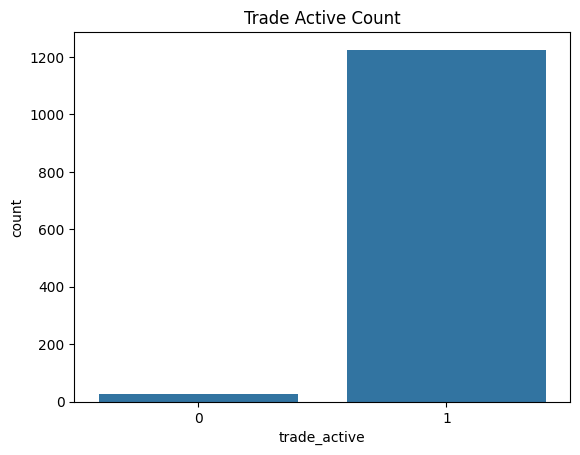

In [22]:
sns.countplot(
    x='trade_active',
    data=trade_flows
)

plt.title("Trade Active Count")

plt.show()

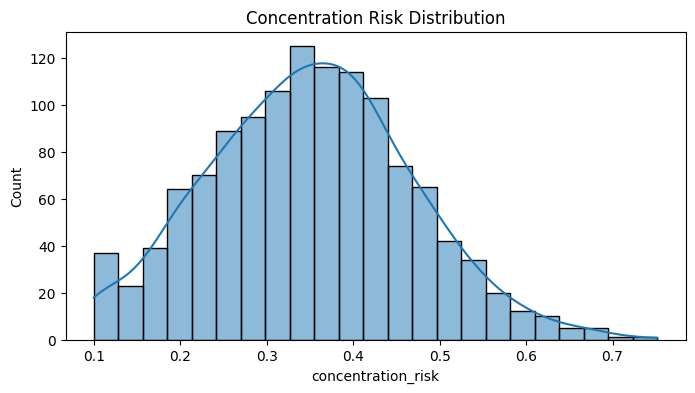

In [23]:

plt.figure(figsize=(8,4))

sns.histplot(
    trade_flows['concentration_risk'],
    kde=True
)

plt.title("Concentration Risk Distribution")

plt.show()

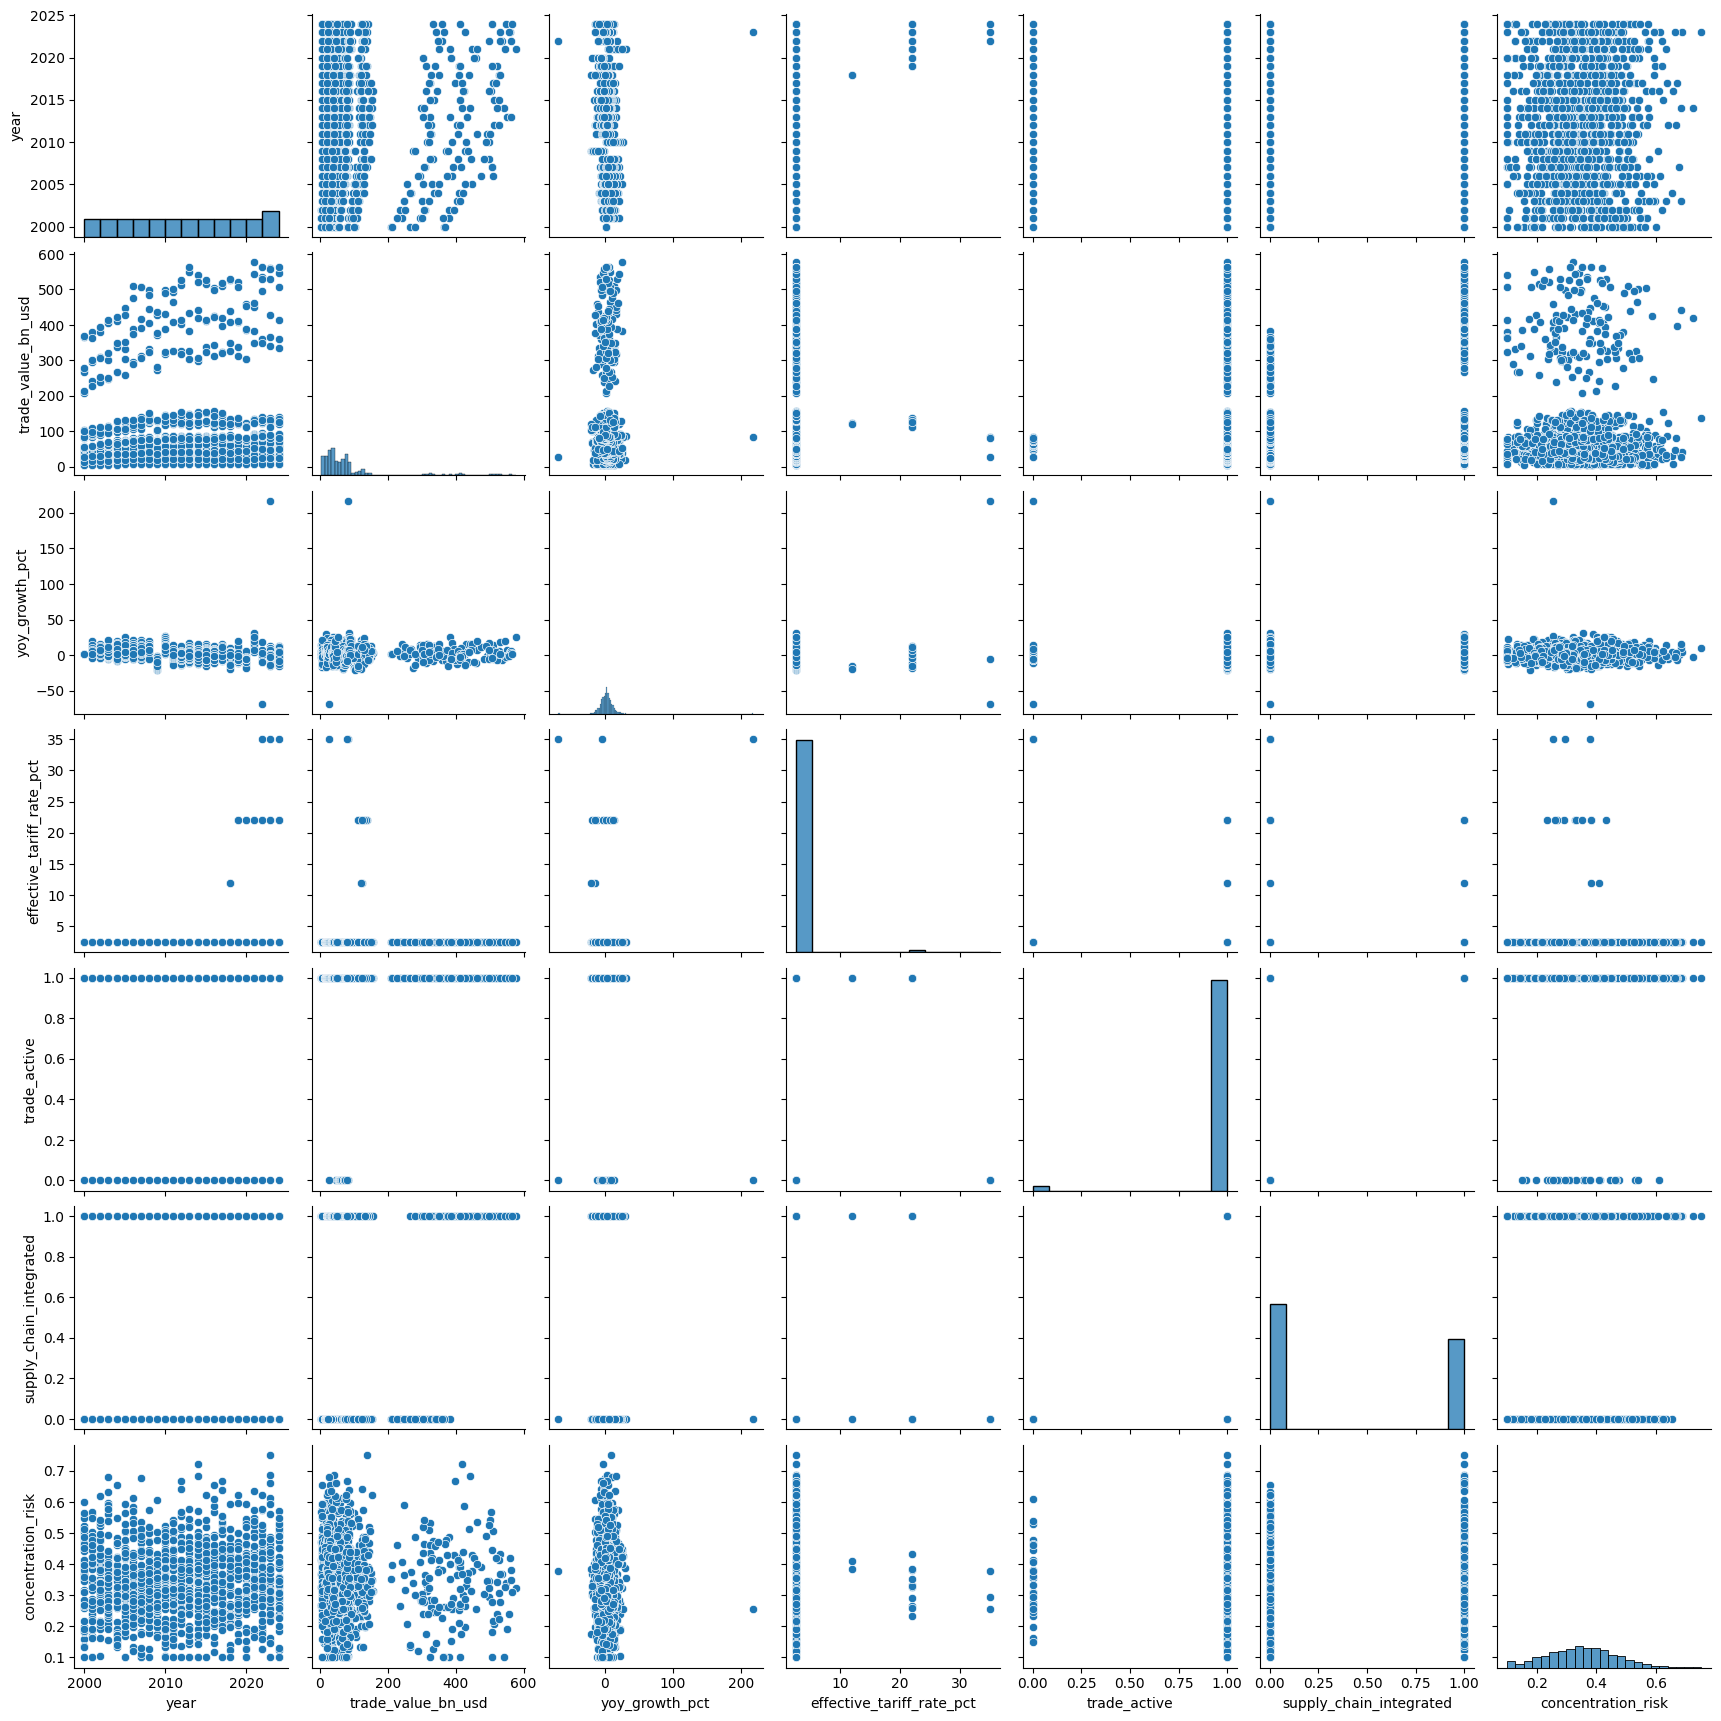

In [24]:

sns.pairplot(
    trade_flows[numerical_cols]
)

plt.show()

## Feature Engineering

First 5 Rows
   year   exporter importer trade_category          key_goods  \
0  2000  Australia    China    commodities  iron ore,coal,LNG   
1  2001  Australia    China    commodities  iron ore,coal,LNG   
2  2002  Australia    China    commodities  iron ore,coal,LNG   
3  2003  Australia    China    commodities  iron ore,coal,LNG   
4  2004  Australia    China    commodities  iron ore,coal,LNG   

   trade_value_bn_usd  yoy_growth_pct  effective_tariff_rate_pct  \
0               23.18           2.105                        2.5   
1               26.71          15.230                        2.5   
2               26.44          -1.010                        2.5   
3               27.68           4.690                        2.5   
4               29.89           7.980                        2.5   

   trade_active  supply_chain_integrated  concentration_risk  
0             1                        0               0.158  
1             1                        0               0.404 

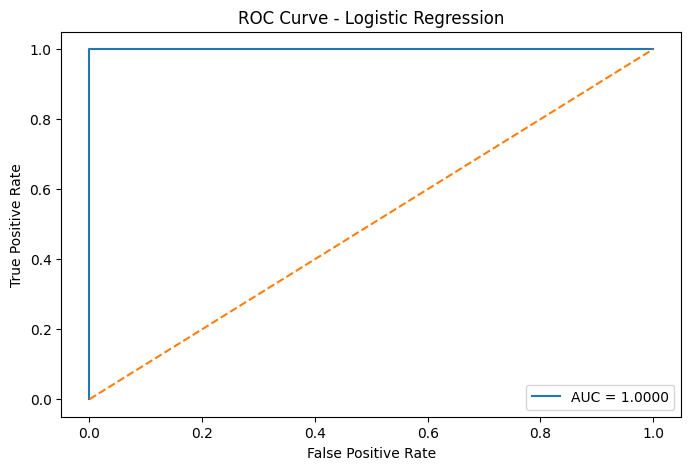


DECISION TREE

Accuracy : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00       245

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250


Confusion Matrix
[[  5   0]
 [  0 245]]


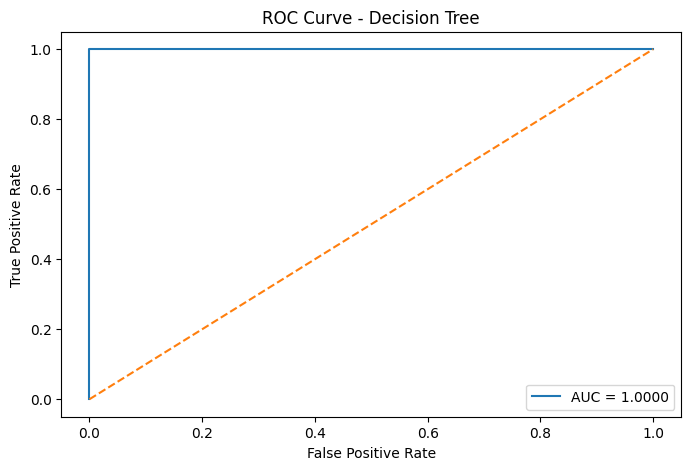


RANDOM FOREST

Accuracy : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00       245

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250


Confusion Matrix
[[  5   0]
 [  0 245]]


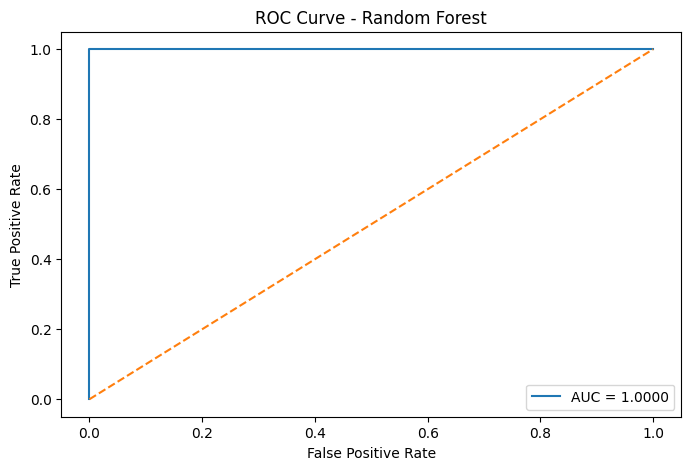


NAIVE BAYES

Accuracy : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00       245

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250


Confusion Matrix
[[  5   0]
 [  0 245]]


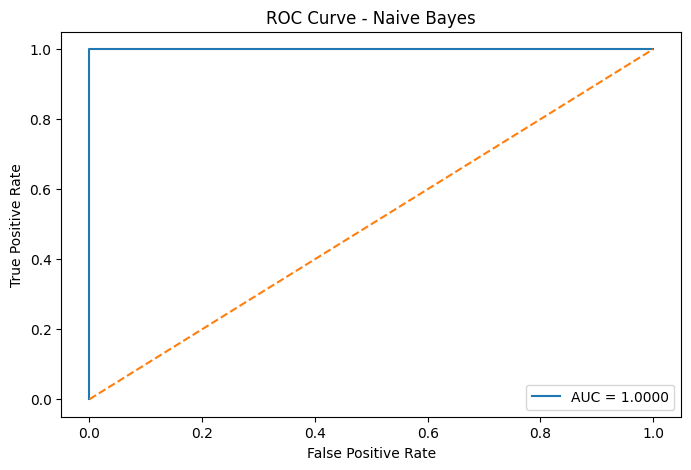


MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2        Random Forest       1.0
3          Naive Bayes       1.0


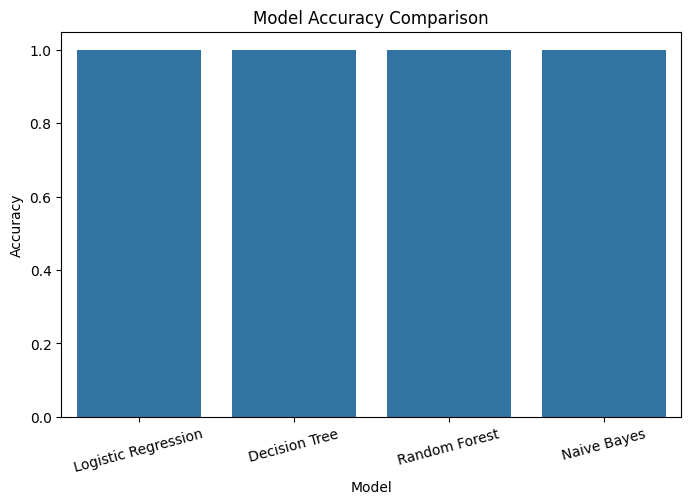


Best Model
                 Model  Accuracy
0  Logistic Regression       1.0


In [25]:
# =========================================================
# GLOBAL SUPPLY CHAIN TRADE DATASET - MACHINE LEARNING CODE
# =========================================================

# =========================
# 1. Import Libraries
# =========================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


# =========================
# 3. Display Dataset
# =========================

print("First 5 Rows")
print(trade_flows.head())

print("\nDataset Shape")
print(trade_flows.shape)

print("\nDataset Info")
print(trade_flows.info())

# =========================
# 4. Define Columns
# =========================

numerical_cols = [
    'year',
    'trade_value_bn_usd',
    'yoy_growth_pct',
    'effective_tariff_rate_pct',
    'supply_chain_integrated',
    'concentration_risk'
]

categorical_cols = [
    'exporter',
    'importer',
    'trade_category',
    'key_goods'
]

# =========================
# 5. Define Features & Target
# =========================

X = trade_flows[numerical_cols + categorical_cols]

y = trade_flows['trade_active']

print("\nFeature Shape :", X.shape)
print("Target Shape :", y.shape)

# =========================
# 6. Train Test Split
# =========================
# Split BEFORE preprocessing to avoid data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nX_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)

# =========================
# 7. Preprocessing Pipeline
# =========================

# Numerical Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# =========================================================
# 8. LOGISTIC REGRESSION
# =========================================================

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Train Model
logistic_pipeline.fit(X_train, y_train)

# Prediction
y_pred_log = logistic_pipeline.predict(X_test)

# Probability Prediction
y_prob_log = logistic_pipeline.predict_proba(X_test)[:, 1]

# Accuracy
log_acc = accuracy_score(y_test, y_pred_log)

print("\nAccuracy :", log_acc)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

roc_auc = roc_auc_score(y_test, y_prob_log)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

# =========================================================
# 9. DECISION TREE
# =========================================================

print("\n==============================")
print("DECISION TREE")
print("==============================")

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

# Train
tree_pipeline.fit(X_train, y_train)

# Prediction
y_pred_tree = tree_pipeline.predict(X_test)

# Probability
y_prob_tree = tree_pipeline.predict_proba(X_test)[:, 1]

# Accuracy
tree_acc = accuracy_score(y_test, y_pred_tree)

print("\nAccuracy :", tree_acc)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_tree))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_tree))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)

roc_auc = roc_auc_score(y_test, y_prob_tree)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.show()

# =========================================================
# 10. RANDOM FOREST
# =========================================================

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_pipeline.predict(X_test)

# Probability
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)

print("\nAccuracy :", rf_acc)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

roc_auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

# =========================================================
# 11. NAIVE BAYES
# =========================================================

print("\n==============================")
print("NAIVE BAYES")
print("==============================")

# Preprocess separately
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense
X_train_dense = X_train_processed.toarray()

X_test_dense = X_test_processed.toarray()

# Train Model
nb_model = GaussianNB()

nb_model.fit(X_train_dense, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test_dense)

# Probability
y_prob_nb = nb_model.predict_proba(X_test_dense)[:, 1]

# Accuracy
nb_acc = accuracy_score(y_test, y_pred_nb)

print("\nAccuracy :", nb_acc)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_nb))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)

roc_auc = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Naive Bayes")

plt.legend()

plt.show()

# =========================================================
# 12. MODEL COMPARISON
# =========================================================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Naive Bayes'
    ],
    'Accuracy': [
        log_acc,
        tree_acc,
        rf_acc,
        nb_acc
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(results)

# =========================
# 13. Accuracy Comparison Plot
# =========================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

# =========================
# 14. Best Model
# =========================

best_model = results.sort_values(
    by='Accuracy',
    ascending=False
)

print("\nBest Model")
print(best_model.head(1))

## Thank you...pls upvote!!!!!